# Mixed Init-Route Dataset Generation

Строит **смешанный** seeded-route датасет: каждому графу назначается набор
маршрутов, сгенерированный одним из методов. Raw-графы либо грузятся из
`raw_graphs_1000.pkl`, либо **перегенерируются** на заданное число узлов
(`REGENERATE_RAW_GRAPHS` / `RAW_N_NODES`) через `DynamicCityGraphDataset`.

## Типы генерации (общий контракт длины [MIN_ROUTE_LEN, MAX_ROUTE_LEN])

| Тип | Метод | Длина | Особенность |
|---|---|---|---|
| `heuristic` | NX max-length heuristic | ровно `max_len` | фиксированная длина |
| `lc`        | LC construction | `min..max` | **ОДИН тип**; графы делятся 33/33/33 по alpha 0 / 0.5 / 1 (`demand_time_weight=alpha`, `route_time_weight=1-alpha`, connectivity off) |
| `rpc`       | Random path combiner | `min..max` | случайные кратчайшие пути |

`N_PER_TYPE` — сколько графов на каждый тип. Итого графов =
`N_PER_TYPE * 3`, каждый берётся из своего raw-графа.

LC/RPC прогоняются через проверенный tensor-путь (`run_lc` / `build_rpc_routes`
с `tensors=...`), который строит корректные node-фичи для модели (иначе
`FeatureNorm` падает по размерности).

## Что сохраняется (в `NEW_DATASET_DIR`)

- `graph_XXXX/lc_<type>_graph_XXXX_routes_routes.pkl` — маршруты (формат
  читается `load_raw_graphs_and_lc_routes`);
- `graph_XXXX/metrics.txt`;
- `raw_graphs_subset.pkl` — raw-графы, выровненные по индексам `graph_XXXX/`
  (нужно для загрузки датасета целиком, особенно при перегенерации);
- `all_results_summary.csv`.

In [1]:
import os as _os, sys as _sys
_NB_DIR = _os.path.abspath(".")
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)

import pickle
import random as _random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch_geometric.data import Batch
from IPython.display import display

import eval_lib
from eval_lib import *  # noqa: F401,F403
from eval_lib import plots as _plots

from connectpt.routes_generator.nx_heuristic import build_nx_heuristic_routes
from connectpt.routes_generator.citygraph_dataset import (
    STOP_KEY, DynamicCityGraphDataset)
from connectpt.routes_generator.transit_time_estimator import RouteGenBatchState
from connectpt.routes_generator.torch_utils import dump_routes
from connectpt.routes_generator.improvement_learning import (
    load_raw_graphs_and_lc_routes)
import connectpt.routes_generator.utils as lrnu
from connectpt.routes_generator.utils import get_eval_cfg

pd.set_option("display.max_columns", None)
print("eval_lib + connectpt loaded")

eval_lib + connectpt loaded


## Конфигурация

In [2]:
# --- Главный knob: графов на КАЖДЫЙ тип ---
# LC -- ОДИН тип; его N_PER_TYPE графов делятся на 3 блока по ~33% между
# alpha 0 / 0.5 / 1 (кратно 3 -> ровно поровну).
N_PER_TYPE = 500

# --- Перегенерация raw-графов с заданным числом узлов ---
# False -> грузим готовый raw_graphs_1000.pkl (50 узлов).
# True  -> генерим свежие случайные графы на RAW_N_NODES узлов
#          (через DynamicCityGraphDataset, как создавался исходный пул).
REGENERATE_RAW_GRAPHS = True
RAW_N_NODES           = 100       # число узлов при перегенерации (>= MAX_ROUTE_LEN)
RAW_GRAPH_DATA_TYPE   = "mixed"   # топология street-графа: mixed/mst/voronoi/grid4...
RAW_GRAPH_SEED        = 0

# --- Контракт маршрутов ---
N_ROUTES_OUT  = 40     # маршрутов на граф
MIN_ROUTE_LEN = 10     # общий min длины маршрута
MAX_ROUTE_LEN = 20     # общий max длины маршрута
LC_N_SAMPLES  = 1      # сэмплов конструктора LC (берётся лучший по cost)
RPC_N_SAMPLES = 1      # RPC: один сэмпл (как в benchmark)

# Все типы используют общий контракт длины [MIN_ROUTE_LEN, MAX_ROUTE_LEN].
# NX-эвристика по своей природе выдаёт маршруты РОВНО max_len; min задаёт лишь
# пул seed-путей (min<max даёт богаче пул и лучше покрытие на больших графах).
HEURISTIC_MIN_LEN = MIN_ROUTE_LEN
RPC_MIN_LEN       = MIN_ROUTE_LEN
LC_MIN_LEN        = MIN_ROUTE_LEN

DATASET_SEED = 0

# Сколько графов на тип показывать в визуализации (полный датасет огромен,
# рисовать все N_PER_TYPE*3 нельзя).
VIZ_PER_TYPE = 2

NEW_DATASET_DIR = DATASETS_DIR / "mixed_init_routes_40r_len20_n100"

# LC -- ОДИН тип; его графы делятся блоками по ~33% между тремя наборами
# коэффициентов (alpha = demand_time_weight, route_time_weight = 1 - alpha,
# connectivity = 0). См. _lc_alpha_assignment в build-ячейке.
LC_WEIGHT_COMBOS = [
    {"alpha": 0.0, "tag": "route-only"},
    {"alpha": 0.5, "tag": "balanced"},
    {"alpha": 1.0, "tag": "demand-only"},
]

GENERATION_TYPES = [
    {"key": "heuristic", "method": "nx_heuristic",
     "label": f"NX heuristic (fixed len={MAX_ROUTE_LEN})",
     "min_len": HEURISTIC_MIN_LEN, "max_len": MAX_ROUTE_LEN,
     "n_samples": None},
    {"key": "lc", "method": "lc",
     "label": "LC (alpha 0/0.5/1 split 33/33/33)",
     "min_len": LC_MIN_LEN, "max_len": MAX_ROUTE_LEN,
     "n_samples": LC_N_SAMPLES},
    {"key": "rpc", "method": "rpc",
     "label": f"RPC (len {RPC_MIN_LEN}-{MAX_ROUTE_LEN})",
     "min_len": RPC_MIN_LEN, "max_len": MAX_ROUTE_LEN,
     "n_samples": RPC_N_SAMPLES},
]

if REGENERATE_RAW_GRAPHS and RAW_N_NODES < MAX_ROUTE_LEN:
    print(f"[warn] RAW_N_NODES={RAW_N_NODES} < MAX_ROUTE_LEN={MAX_ROUTE_LEN}: "
          f"NX-эвристика требует n_nodes >= max_route_len; уменьши MAX_ROUTE_LEN "
          f"или увеличь RAW_N_NODES.")

print(f"N_PER_TYPE:      {N_PER_TYPE}  (графов на тип; LC делится 33/33/33 по alpha)")
print(f"Regenerate raw:  {REGENERATE_RAW_GRAPHS}"
      + (f"  (n_nodes={RAW_N_NODES}, type={RAW_GRAPH_DATA_TYPE})"
         if REGENERATE_RAW_GRAPHS else "  (load raw_graphs_1000.pkl)"))
print(f"Types:           {[t['key'] for t in GENERATION_TYPES]}")
print(f"LC alpha combos: {[c['alpha'] for c in LC_WEIGHT_COMBOS]} (по ~33%)")
print(f"Route contract:  n_routes={N_ROUTES_OUT}, len[{MIN_ROUTE_LEN}, {MAX_ROUTE_LEN}]")
print(f"Total graphs:    {N_PER_TYPE * len(GENERATION_TYPES)}")
print(f"Output dir:      {NEW_DATASET_DIR}")

N_PER_TYPE:      500  (графов на тип; LC делится 33/33/33 по alpha)
Regenerate raw:  True  (n_nodes=100, type=mixed)
Types:           ['heuristic', 'lc', 'rpc']
LC alpha combos: [0.0, 0.5, 1.0] (по ~33%)
Route contract:  n_routes=40, len[10, 20]
Total graphs:    1500
Output dir:      D:\PythonProjects\connectpt\datasets\mixed_init_routes_40r_len20_n100


## Вспомогательные функции

- общий `EVAL_COST_OBJ` для сопоставимых метрик (cost/ATT/RTT/d_un) по всем типам;
- `run_construction_on_graph` — гоняет LC/RPC модель напрямую на сыром графе
  (через 1-граф DataLoader, без ре-трансформации тензоров);
- `generate_routes_for_type` — диспетчер по методам;
- `_to_fixed_route_tensor` — приводит результат к `[n_routes, max_len]` с -1-паддингом.

In [ ]:
# Общий cost-objective: метрики всех типов считаются под одним балансом
# (по умолчанию из eval_model_mumford), чтобы строки таблицы были сравнимы.
_eval_cfg = get_eval_cfg(
    str(CFG_DIR), "eval_model_mumford",
    {"dataset_name": "tensor", "n_routes": N_ROUTES_OUT,
     "min_route_len": 1, "max_route_len": MAX_ROUTE_LEN,
     "run_name": "mixed_init_eval"})
_eval_cfg.batch_size = 1
EVAL_DEVICE, _, _, EVAL_COST_OBJ, _ = lrnu.process_standard_experiment_cfg(
    _eval_cfg, run_name_prefix="mixed_init_eval_", weights_required=False)
EVAL_COST_OBJ.ignore_stops_oob = True
print(f"Eval device: {EVAL_DEVICE}")


def load_or_generate_raw_graphs(n_needed):
    """Вернуть список raw-графов.

    REGENERATE_RAW_GRAPHS=False -> грузим готовый raw_graphs_1000.pkl.
    REGENERATE_RAW_GRAPHS=True  -> генерим n_needed свежих графов на RAW_N_NODES
    узлов через DynamicCityGraphDataset (как создавался исходный пул), с фикс.
    seed для детерминизма.

    ВАЖНО: НЕ применяем ds.transform (InsertPosFeatures). Оригинальный пул
    raw_graphs_1000.pkl хранит node-фичи x=[N,2] (get_node_features: степени,
    БЕЗ pos); pos добавляется уже в обучении (make_improvement_batch). Если
    применить transform здесь, x станет [N,4] -> DemandScaleTransform при
    обучении видит x.shape[1]>2 и лезет в demand-фичи (idx 4/5) -> IndexError.
    """
    if not REGENERATE_RAW_GRAPHS:
        graphs = pd.read_pickle(RAW_GRAPHS_PATH)
        print(f"Loaded {len(graphs)} raw graphs from {RAW_GRAPHS_PATH}")
        return graphs

    _random.seed(RAW_GRAPH_SEED)
    torch.manual_seed(RAW_GRAPH_SEED)
    ds = DynamicCityGraphDataset(
        min_nodes=RAW_N_NODES, max_nodes=RAW_N_NODES,
        data_type=RAW_GRAPH_DATA_TYPE, mumford_style=True, pos_only=False)
    graphs = [ds.generate_graph(n_nodes=RAW_N_NODES) for _ in range(int(n_needed))]
    print(f"Regenerated {len(graphs)} raw graphs "
          f"(n_nodes={RAW_N_NODES}, data_type={RAW_GRAPH_DATA_TYPE}, "
          f"seed={RAW_GRAPH_SEED}); node-feat x shape = "
          f"{tuple(graphs[0][STOP_KEY].x.shape)}")
    return graphs


def tensors_from_graph(graph):
    """Extract {node_locs, street_adj, demand} from a raw CityGraphData.

    The LC / RPC construction models need the full transformed node-feature
    vector (extra node feats), produced by the tensor-dataset path
    (`from_tensors_with_transformations` inside get_dataset_from_config).
    Feeding the raw graph object straight into the model skips that and
    crashes FeatureNorm with a dimensionality mismatch, so we round-trip
    through tensors -- the same path the benchmark RPC/LC generation uses.
    """
    return {
        "node_locs": graph[STOP_KEY].pos.detach().cpu().clone(),
        "street_adj": graph.street_adj.detach().cpu().clone(),
        "demand": graph.demand.detach().cpu().clone(),
    }


def _to_fixed_route_tensor(routes, n_routes, max_route_len):
    """Normalize any route output to [n_routes, max_route_len] with -1 padding."""
    t = as_route_tensor(routes).long()
    if t.ndim == 3:
        t = t[0]
    if t.shape[0] < n_routes:
        pad = torch.full((n_routes - t.shape[0], t.shape[1]), -1, dtype=t.dtype)
        t = torch.cat([t, pad], dim=0)
    elif t.shape[0] > n_routes:
        t = t[:n_routes]
    if t.shape[1] < max_route_len:
        pad = torch.full((t.shape[0], max_route_len - t.shape[1]), -1, dtype=t.dtype)
        t = torch.cat([t, pad], dim=1)
    elif t.shape[1] > max_route_len:
        if (t[:, max_route_len:] >= 0).any():
            raise ValueError("route exceeds max_route_len with real stops")
        t = t[:, :max_route_len]
    return t


def generate_routes_for_type(tcfg, graph, seed, alpha=None):
    """Generate one route set for `graph` using the method in `tcfg`.

    LC/RPC go through the proven tensor-dataset path (run_lc / build_rpc_routes
    with tensors=...), which builds the correct node features for the model.
    `alpha` is the LC demand_time_weight (route_time_weight = 1 - alpha).
    """
    method = tcfg["method"]
    torch.manual_seed(seed)
    if method == "nx_heuristic":
        try:
            routes = build_nx_heuristic_routes(
                graph, num_routes=N_ROUTES_OUT,
                min_len=tcfg["min_len"], max_len=tcfg["max_len"], seed=seed)
        except ValueError as exc:
            print(f"  [heuristic] min_len={tcfg['min_len']} failed ({exc}); "
                  f"falling back to min_len=2")
            routes = build_nx_heuristic_routes(
                graph, num_routes=N_ROUTES_OUT,
                min_len=2, max_len=tcfg["max_len"], seed=seed)
    elif method == "lc":
        a = float(alpha)
        cfg = build_lc_cfg(
            run_name=f"mixed_lc_a{a}",
            n_routes=N_ROUTES_OUT,
            min_route_len=tcfg["min_len"], max_route_len=tcfg["max_len"],
            demand_time_weight=a,
            route_time_weight=1.0 - a,
            median_connectivity_weight=0.0)
        _, _m, _u, routes, _sc = run_lc(
            cfg, tensors=tensors_from_graph(graph),
            run_name_prefix="mixed_lc_", n_samples=tcfg["n_samples"])
    elif method == "rpc":
        spec = {"city": "mixed", "n_routes": N_ROUTES_OUT,
                "min_route_len": tcfg["min_len"], "max_route_len": tcfg["max_len"]}
        routes = build_rpc_routes(
            spec, tensors_from_graph(graph),
            run_name=f"mixed_rpc_{seed}", n_samples=tcfg["n_samples"])
    else:
        raise ValueError(f"unknown method {method}")
    return _to_fixed_route_tensor(routes, N_ROUTES_OUT, MAX_ROUTE_LEN)


def evaluate_route_set(graph, routes_tensor):
    """Score a route set under the shared EVAL_COST_OBJ for comparable metrics."""
    graph_batch = Batch.from_data_list([graph.clone()]).to(EVAL_DEVICE)
    rt = routes_tensor.to(EVAL_DEVICE)
    if rt.ndim == 2:
        rt = rt[None]
    state = RouteGenBatchState(
        graph_batch, EVAL_COST_OBJ, N_ROUTES_OUT, 1, MAX_ROUTE_LEN)
    state.add_new_routes(rt)
    result = EVAL_COST_OBJ(state)
    out = {}
    for key, val in result.get_metrics().items():
        if torch.is_tensor(val):
            val = val.detach().reshape(-1)[0].cpu().item()
        out[key] = float(val)
    return out


print("helpers ready")

## Генерация датасета

In [4]:
_n_needed = N_PER_TYPE * len(GENERATION_TYPES)
raw_graphs = load_or_generate_raw_graphs(_n_needed)
print()

NEW_DATASET_DIR.mkdir(parents=True, exist_ok=True)


def _lc_alpha_assignment(n_lc):
    """Split n_lc graphs into 3 ~equal (33/33/34) contiguous blocks, one per
    LC_WEIGHT_COMBOS entry. Returns a list of combo dicts of length n_lc.

    Это и есть деление LC-типа: alpha 0 / 0.5 / 1 делят графы LC по ~33% каждый,
    оставаясь ОДНИМ типом 'lc'."""
    assignment = [None] * n_lc
    for combo, block in zip(LC_WEIGHT_COMBOS, np.array_split(np.arange(n_lc), 3)):
        for idx in block.tolist():
            assignment[idx] = combo
    return assignment


# Предварительно строим alpha-разбиение для LC-типа (блоки по ~33%).
LC_ALPHA_ASSIGNMENT = _lc_alpha_assignment(N_PER_TYPE)

records = []
subset_graphs = []
GENERATED_ROUTES = {}   # global_idx -> route tensor [n_routes, max_len]
global_idx = 0
source_idx = 0

for tcfg in GENERATION_TYPES:
    for type_local_idx in range(N_PER_TYPE):
        if source_idx >= len(raw_graphs):
            raise RuntimeError("Ran out of raw graphs for the requested counts")
        graph = raw_graphs[source_idx]
        seed = DATASET_SEED + global_idx

        # LC -- ОДИН тип; alpha 0/0.5/1 делят его графы блоками по ~33%.
        if tcfg["method"] == "lc":
            combo = LC_ALPHA_ASSIGNMENT[type_local_idx]
            alpha = combo["alpha"]
            combo_tag = combo["tag"]
            label = f"{tcfg['label']} -- {combo_tag} (a={alpha})"
        else:
            alpha, combo_tag, label = None, None, tcfg["label"]

        routes = generate_routes_for_type(tcfg, graph, seed, alpha=alpha)
        metrics = evaluate_route_set(graph, routes)

        graph_dir = NEW_DATASET_DIR / f"graph_{global_idx:04d}"
        graph_dir.mkdir(parents=True, exist_ok=True)
        run_name = f"lc_{tcfg['key']}_graph_{global_idx:04d}"
        dump_routes(f"{run_name}_routes", routes, out_dir=graph_dir)

        route_lens = [int((r >= 0).sum().item()) for r in routes]
        covered = len({int(n) for r in routes for n in r.tolist() if n >= 0})
        rec = {
            "global_index": global_idx,
            "source_graph_index": source_idx,
            "type_key": tcfg["key"],
            "method": tcfg["method"],
            "label": label,
            "alpha": alpha,
            "combo": combo_tag,
            "n_samples": tcfg["n_samples"],
            "min_len": tcfg["min_len"],
            "max_len": tcfg["max_len"],
            "n_routes": N_ROUTES_OUT,
            "n_nodes": int(graph[STOP_KEY].num_nodes),
            "route_len_min": int(min(route_lens)),
            "route_len_mean": float(np.mean(route_lens)),
            "route_len_max": int(max(route_lens)),
            "covered_nodes": covered,
            "cost": metrics.get("cost", float("nan")),
            "ATT": metrics.get("ATT", float("nan")),
            "RTT": metrics.get("RTT", float("nan")),
            "d_un": metrics.get("$d_{un}$", float("nan")),
            "run_name": run_name,
        }
        with open(graph_dir / "metrics.txt", "w", encoding="utf-8") as fh:
            for key, val in rec.items():
                fh.write(f"{key}: {val}\n")

        records.append(rec)
        subset_graphs.append(graph)
        GENERATED_ROUTES[global_idx] = routes
        print(f"[{global_idx:04d}] {label:42s} "
              f"src={source_idx:<4d} n={rec['n_nodes']} cost={rec['cost']:.4f} "
              f"len[{rec['route_len_min']}-{rec['route_len_max']}] "
              f"covered={covered}/{rec['n_nodes']}")
        global_idx += 1
        source_idx += 1

# подмножество сырых графов, выровненное по индексам graph_XXXX
subset_path = NEW_DATASET_DIR / "raw_graphs_subset.pkl"
with subset_path.open("wb") as fh:
    pickle.dump(subset_graphs, fh)

summary_df = pd.DataFrame(records)
summary_df.to_csv(NEW_DATASET_DIR / "all_results_summary.csv", index=False)

# Контроль: распределение alpha внутри LC-типа (должно быть ~33/33/34).
_lc = summary_df[summary_df["method"] == "lc"]
if len(_lc):
    print("\nLC alpha split (один тип, ~33% каждый):")
    print(_lc["alpha"].value_counts().sort_index().to_string())

print(f"\nDataset dir:    {NEW_DATASET_DIR}")
print(f"Subset graphs:  {subset_path}  ({len(subset_graphs)} graphs)")
print(f"Summary CSV:    {NEW_DATASET_DIR / 'all_results_summary.csv'}")
display(summary_df)

Regenerated 1500 raw graphs (n_nodes=100, data_type=mixed, seed=0)

[0000] NX heuristic (fixed len=20)                src=0    n=100 cost=1.3845 len[20-20] covered=98/100
[0001] NX heuristic (fixed len=20)                src=1    n=100 cost=2.0252 len[20-20] covered=97/100
[0002] NX heuristic (fixed len=20)                src=2    n=100 cost=1.0394 len[20-20] covered=100/100
[0003] NX heuristic (fixed len=20)                src=3    n=100 cost=1.6209 len[20-20] covered=98/100
[0004] NX heuristic (fixed len=20)                src=4    n=100 cost=1.7102 len[20-20] covered=96/100
[0005] NX heuristic (fixed len=20)                src=5    n=100 cost=1.7476 len[20-20] covered=95/100
[0006] NX heuristic (fixed len=20)                src=6    n=100 cost=2.2160 len[20-20] covered=92/100
[0007] NX heuristic (fixed len=20)                src=7    n=100 cost=1.4579 len[20-20] covered=99/100
[0008] NX heuristic (fixed len=20)                src=8    n=100 cost=1.0144 len[20-20] covered=100/100
[00

D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:313: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


[0500] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=500  n=100 cost=0.6756 len[10-14] covered=100/100
[0501] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=501  n=100 cost=0.4291 len[4-20] covered=100/100
[0502] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=502  n=100 cost=0.4429 len[4-20] covered=100/100
[0503] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=503  n=100 cost=0.5513 len[10-20] covered=100/100
[0504] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=504  n=100 cost=0.5986 len[10-20] covered=100/100
[0505] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=505  n=100 cost=0.3888 len[6-20] covered=100/100
[0506] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=506  n=100 cost=0.6243 len[9-17] covered=100/100
[0507] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=507  n=100 cost=0.6604 len[8-15] covered=100/100
[0508] LC (alpha 0/0.5/1 split 33/33/33) -- route-only (a=0.0) src=50

,global_index,source_graph_index,type_key,method,label,alpha,combo,n_samples,min_len,max_len,n_routes,n_nodes,route_len_min,route_len_mean,route_len_max,covered_nodes,cost,ATT,RTT,d_un,run_name
0,0,0,heuristic,nx_heuristic,NX heuristic (fixed len=20),NaN,NaN,NaN,10,20,40,100,20,20.000,20,98,1.384539,42.501095,5928.708984,4.477941,lc_heuristic_graph_0000
1,1,1,heuristic,nx_heuristic,NX heuristic (fixed len=20),NaN,NaN,NaN,10,20,40,100,20,20.000,20,97,2.025221,26.297655,5651.796875,6.919524,lc_heuristic_graph_0001
2,2,2,heuristic,nx_heuristic,NX heuristic (fixed len=20),NaN,NaN,NaN,10,20,40,100,20,20.000,20,100,1.039365,23.095089,4541.047363,0.724131,lc_heuristic_graph_0002
3,3,3,heuristic,nx_heuristic,NX heuristic (fixed len=20),NaN,NaN,NaN,10,20,40,100,20,20.000,20,98,1.620892,36.051739,6419.676270,5.948873,lc_heuristic_graph_0003
4,4,4,heuristic,nx_heuristic,NX heuristic (fixed len=20),NaN,NaN,NaN,10,20,40,100,20,20.000,20,96,1.710211,34.071175,5412.606445,8.024110,lc_heuristic_graph_0004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1495,1495,rpc,rpc,RPC (len 10-20),NaN,NaN,1.0,10,20,40,100,10,13.775,19,97,1.566894,26.445955,3833.361084,6.230844,lc_rpc_graph_1495
1496,1496,1496,rpc,rpc,RPC (len 10-20),NaN,NaN,1.0,10,20,40,100,10,15.325,19,95,1.766322,29.830509,3682.873291,9.876217,lc_rpc_graph_1496
1497,1497,1497,rpc,rpc,RPC (len 10-20),NaN,NaN,1.0,10,20,40,100,4,15.375,20,99,1.116261,40.721046,4119.638672,2.433566,lc_rpc_graph_1497
1498,1498,1498,rpc,rpc,RPC (len 10-20),NaN,NaN,1.0,10,20,40,100,10,15.625,19,97,1.536104,33.543098,4865.880371,6.161536,lc_rpc_graph_1498


## Визуализация графов разных типов

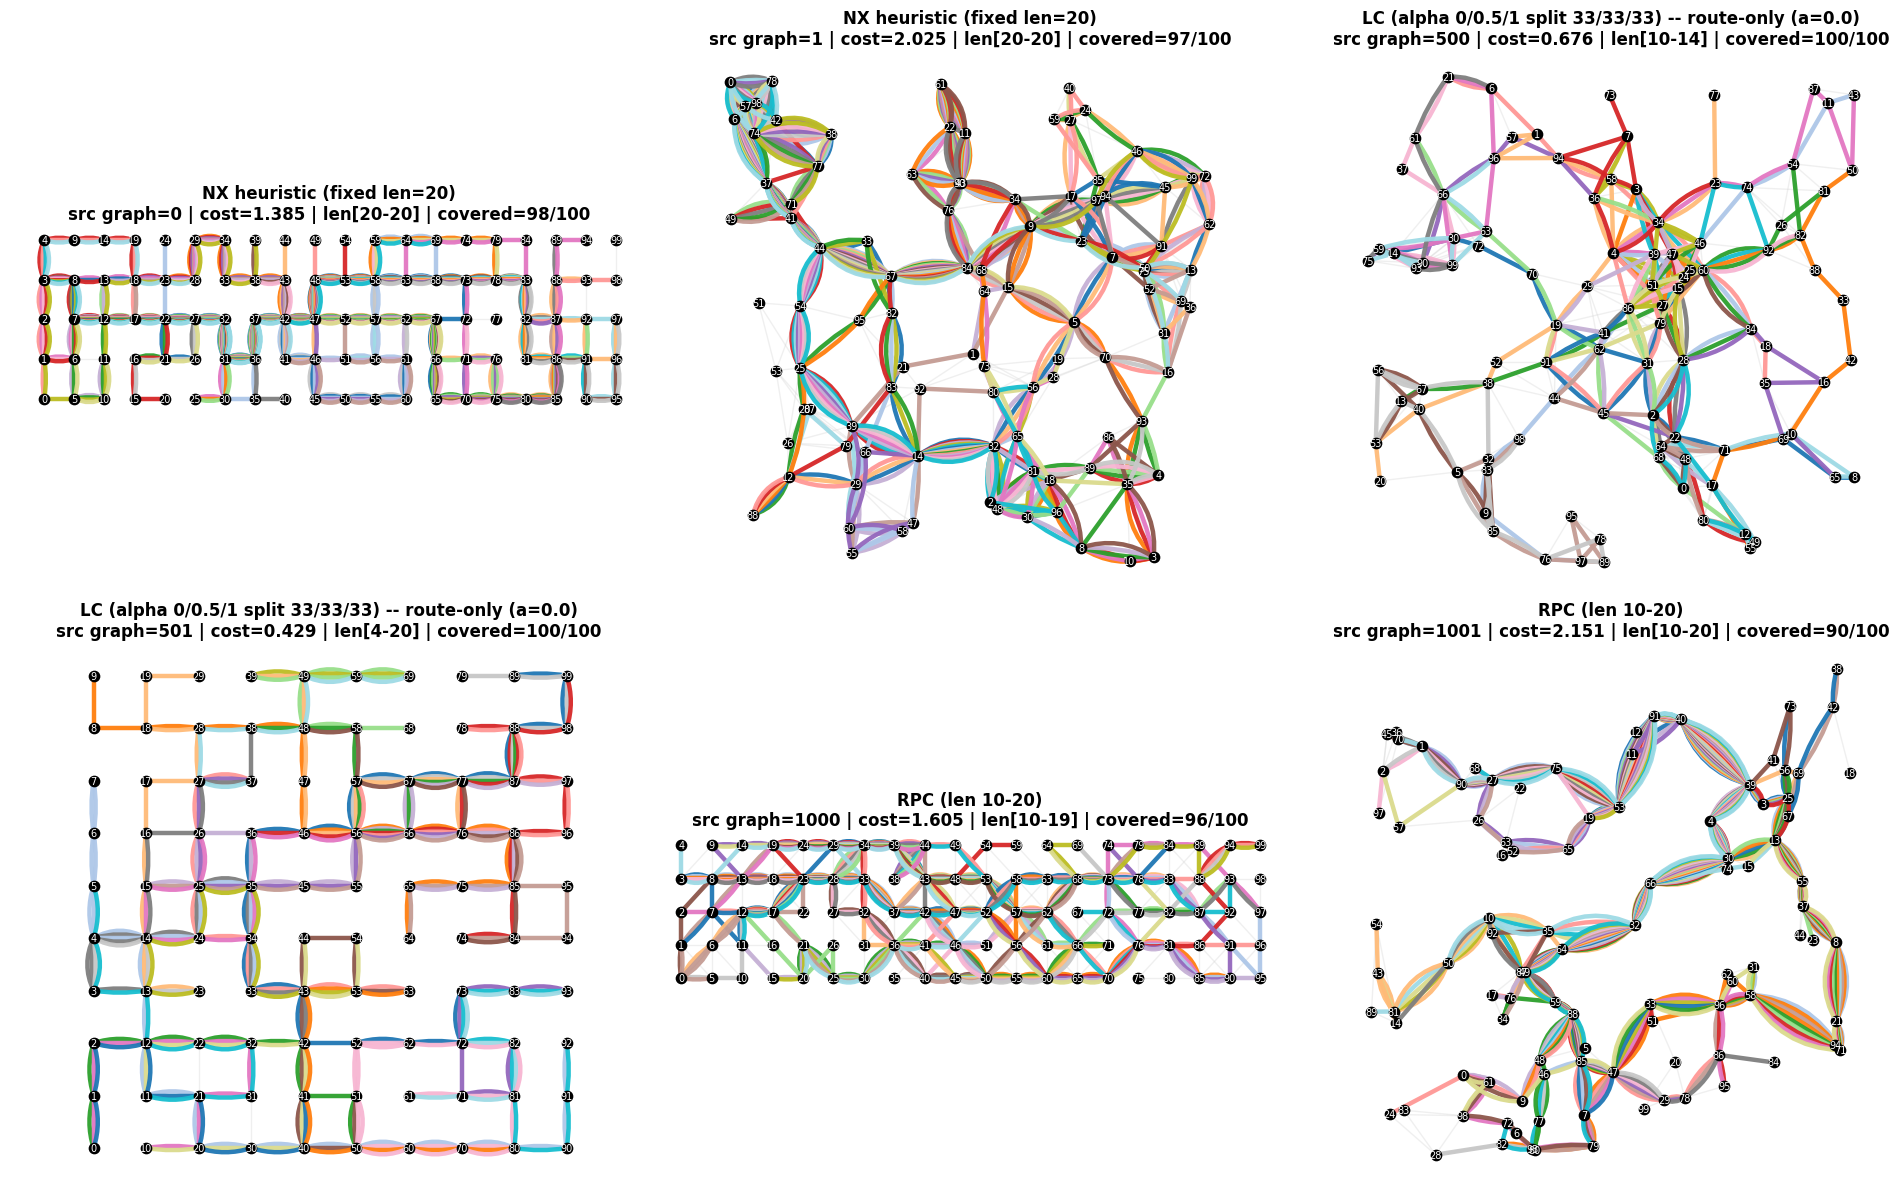

In [5]:
# Полный датасет огромен -> показываем по VIZ_PER_TYPE графов на каждый тип.
_by_type = {}
for rec in records:
    _by_type.setdefault(rec["type_key"], []).append(rec)
viz_recs = []
for _key, _recs in _by_type.items():
    viz_recs.extend(_recs[:VIZ_PER_TYPE])

n_panels = len(viz_recs)
ncols = min(n_panels, 3) if n_panels > 1 else 1
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(6.5 * ncols, 6.0 * nrows), squeeze=False)
axes = axes.flatten()

for ax, rec in zip(axes, viz_recs):
    gi = rec["global_index"]
    graph = subset_graphs[gi]
    routes = GENERATED_ROUTES[gi]
    subtitle = (
        f"src graph={rec['source_graph_index']} | cost={rec['cost']:.3f} | "
        f"len[{rec['route_len_min']}-{rec['route_len_max']}] | "
        f"covered={rec['covered_nodes']}/{rec['n_nodes']}"
    )
    # with_overlap_curves=True -> дублирующиеся/перекрывающиеся рёбра рисуются дугами
    _plots.plot_plain_route_set(
        ax, routes, graph,
        title=rec["label"], subtitle=subtitle,
        palette="tab20", with_overlap_curves=True)

for ax in axes[n_panels:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
plt.close(fig)

## Проверка: загрузка датасета обратно

Грузим через тот же `load_raw_graphs_and_lc_routes`, что использует обучение
(на сохранённом `raw_graphs_subset.pkl`). Подтверждает что формат маршрутов и
выравнивание индексов корректны.

In [6]:
loaded_graphs, loaded_routes = load_raw_graphs_and_lc_routes(
    subset_path, NEW_DATASET_DIR)
route_lens = (loaded_routes >= 0).sum(dim=-1)
nonempty = route_lens[route_lens > 0]

print(f"Loaded graphs:  {len(loaded_graphs)}")
print(f"Routes tensor:  {tuple(loaded_routes.shape)}")
print(f"Route length:   min={int(nonempty.min())}  max={int(nonempty.max())}")
assert len(loaded_graphs) == len(records)

print("\nPer-method route-length / metric means:")
display(
    summary_df.groupby("method")[
        ["route_len_min", "route_len_max", "route_len_mean",
         "cost", "ATT", "RTT", "d_un"]
    ].mean().round(3)
)

Loaded graphs:  1500
Routes tensor:  (1500, 40, 20)
Route length:   min=3  max=20

Per-method route-length / metric means:


,route_len_min,route_len_max,route_len_mean,cost,ATT,RTT,d_un
method,,,,,,,
lc,7.378,18.870,10.755,0.553,34.588,2721.826,5.179
nx_heuristic,20.000,20.000,20.000,1.497,33.133,5597.776,4.543
rpc,9.572,19.294,14.976,1.807,33.264,3950.207,12.064
